# Gender Recognition by Voice (из KAGGLE)

### Задача:

Обучить модель машинного обучения классифицировать людей на мужчин и женщин по их голосу. 

Системе идентификации пола по голосу, основанной на такой модели, можно найти применение во многих областях — от маркетинга до интегрирования в системы безопасности.

Примечание: 

Большинство датасетов из Kaggle состоят из больших массивов размеченных аудиофайлов, обработку которых составители датасетов возлагают на исследователей. Пока что не стоит задачи работать с аудиоинформацией и преобразовывать её в привычный нам формат табличных данных, поэтому для решения данной задачи был найден готовый датасет, в котором все преобразования аудиоинформации в числовой табличный формат уже произведены.

### Данные:

Набор данных состоит из 3 168 записанных образцов голоса мужчин и женщин. Образцы предварительно обрабатываются с помощью акустического анализа на языке программирования R с использованием специальных библиотек в диапазоне частот 0 Гц-280 Гц (диапазон человеческого голоса). Если вкратце, в результате обработки звук на аудиозаписи оцифровывается и преобразуется в числовую последовательность частот, из которой извлекаются различные статистические характеристики, например средняя частота, с которой говорит спикер на аудиозаписи, или частота с наибольшей энергией и так далее.


- meanfreq — средняя частота голоса спикера (в кГц);
- sd — стандартное отклонение частоты (в кГц);
- median — медианная частота (в кГц);
- Q25 — первый квартиль частоты (25-я квантиль) (в кГц);
- Q75 — третий квартиль частоты (75-я квантиль) (в кГц);
- IQR — межквартильный размах (Q75-Q25) (в кГц);
- skew — асимметрия распределения частот;
- kurt — эксцесс распределения частот;
- sp.ent — спектральная энтропия;
- sfm — спектральная равномерность;
- ode — модальная частота (наиболее популярная частота голоса);
- centroid — частотный центроид;
- peakf — пиковая частота (частота с наибольшей энергией);
- meanfun — среднее значение основной частоты, измеренной по акустическому сигналу;
- minfun — минимальное значение основной частоты, измеренной по акустическому сигналу;
- maxfun — максимальное значение основной частоты, измеренной по акустическому сигналу;
- meandom — среднее значение доминирующей частоты, измеренной по акустическому сигналу;
- mindom — минимальное значение доминирующей частоты, измеренной по акустическому сигналу;
- maxdom — максимальное значение доминирующей частоты, измеренной по акустическому сигналу;
- dfrange — диапазон доминирующей частоты, измеренный по акустическому сигналу;
- modindx — индекс модуляции;
---
- label — целевой признак — метка класса: __male__ (голос принадлежит мужчине) или __female__ (голос принадлежит женщине).

### Импорт библиотек:

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn import tree
from sklearn import model_selection
from sklearn import metrics

Прочитаем данные:

In [5]:
voice_data = pd.read_csv('Data/voice_gender.csv')
display(voice_data.head())
display(voice_data.info())

,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,...,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label
0,0.059781,0.064241,0.032027,0.015071,0.090193,0.075122,12.863462,274.402905,0.893369,0.491918,...,0.059781,0.084279,0.015702,0.275862,0.007812,0.007812,0.007812,0.000000,0.000000,male
1,0.066009,0.067310,0.040229,0.019414,0.092666,0.073252,22.423285,634.613855,0.892193,0.513724,...,0.066009,0.107937,0.015826,0.250000,0.009014,0.007812,0.054688,0.046875,0.052632,male
2,0.077316,0.083829,0.036718,0.008701,0.131908,0.123207,30.757155,1024.927705,0.846389,0.478905,...,0.077316,0.098706,0.015656,0.271186,0.007990,0.007812,0.015625,0.007812,0.046512,male
3,0.151228,0.072111,0.158011,0.096582,0.207955,0.111374,1.232831,4.177296,0.963322,0.727232,...,0.151228,0.088965,0.017798,0.250000,0.201497,0.007812,0.562500,0.554688,0.247119,male
4,0.135120,0.079146,0.124656,0.078720,0.206045,0.127325,1.101174,4.333713,0.971955,0.783568,...,0.135120,0.106398,0.016931,0.266667,0.712812,0.007812,5.484375,5.476562,0.208274,male


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3168 entries, 0 to 3167
Data columns (total 21 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   meanfreq  3168 non-null   float64
 1   sd        3168 non-null   float64
 2   median    3168 non-null   float64
 3   Q25       3168 non-null   float64
 4   Q75       3168 non-null   float64
 5   IQR       3168 non-null   float64
 6   skew      3168 non-null   float64
 7   kurt      3168 non-null   float64
 8   sp.ent    3168 non-null   float64
 9   sfm       3168 non-null   float64
 10  mode      3168 non-null   float64
 11  centroid  3168 non-null   float64
 12  meanfun   3168 non-null   float64
 13  minfun    3168 non-null   float64
 14  maxfun    3168 non-null   float64
 15  meandom   3168 non-null   float64
 16  mindom    3168 non-null   float64
 17  maxdom    3168 non-null   float64
 18  dfrange   3168 non-null   float64
 19  modindx   3168 non-null   float64
 20  label     3168 non-null   obje

None

Проверим на пропуски:

In [6]:
display(f'Количество пропусков в данных: {voice_data.isnull().sum().sum()}')

'Количество пропусков в данных: 0'

Общее количество пропусков в датасете равно 0. Значит, обработка пропущенных значений нам не потребуется.

Проведем разведывательных анализ данных, чтобы определить наиболее важные признаки для определения целевой переменной.

In [12]:
X = voice_data.drop('label', axis=1)
y = voice_data['label']

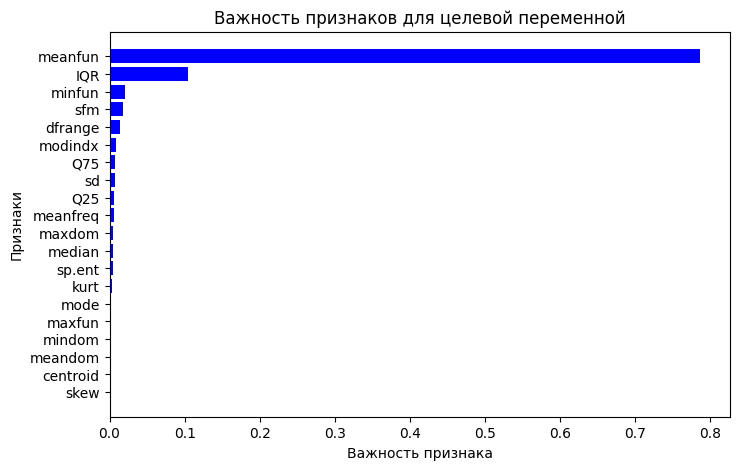

In [16]:
# Создаём модель дерева решений и обучаем её
dt_model = tree.DecisionTreeClassifier(
    criterion='entropy', # критерий информативности
    random_state=1000 # генератор случайных чисел
)

# Обучаем дерево
dt_model.fit(X, y)

# Имена признаков
feature_names = X.columns
# Вычисляем значения информативности признаков
feature_importances = dt_model.feature_importances_

# Сортируем признаки и их важность по убыванию
sorted_features, sorted_importances = zip(*sorted(zip(feature_names, feature_importances), key=lambda x: x[1], reverse=False))

# Визуализация важности признаков
plt.figure(figsize=(8, 5))
plt.barh(
    sorted_features, 
    sorted_importances, 
    color='blue')
plt.xlabel("Важность признака")
plt.ylabel("Признаки")
plt.title("Важность признаков для целевой переменной")
plt.show()

Перейдём к формированию обучающей и тестовой выборок. Разделим датасет на две части в соотношении 80/20:

In [17]:
# Формируем обучающую и тестовую выборки
X_train, X_test, y_train, y_test = model_selection.train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print('Train shape: {}'.format(X_train.shape))
print('Test shape: {}'.format(X_test.shape))

Train shape: (2534, 20)
Test shape: (634, 20)


Начнём с решающего пня.

Создайте модель дерева решений максимальной глубины 1. В качестве критерия информативности используйте энтропию Шеннона.

Обучите модель на тренировочной выборке и визуализируйте её в виде графа.

1. На основе какого фактора будет построено решающее правило в корневой вершине?
2. Чему равно оптимальное пороговое значение для данного фактора? Ответ округлите до трёх знаков после точки-разделителя.
3. Сколько процентов наблюдений, для которых выполняется заданное в корневой вершине условие, содержится в обучающей выборке? Ответ округлите до одного знака после точки-разделителя. Не указывайте в ответе символ %.
4. Сделайте предсказание и рассчитайте значение метрики accuracy на тестовой выборке. Ответ округлите до трёх знаков после точки-разделителя.

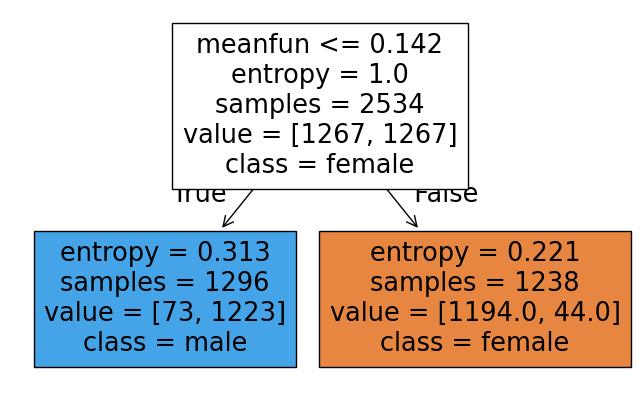

Оптимальное пороговое значение для фактора: 0.142
Процент наблюдений, для которых выполнено условие в корневой вершине: 51.1%
Процент наблюдений, для которых условие НЕ выполнено: 48.9%
Accuracy: 0.956


In [26]:
# Создаем модель дерева решений
dt_model = tree.DecisionTreeClassifier(
    max_depth=1,
    criterion='entropy',
    random_state=42
)

# Обучаем дерево на тренировочной выборке
dt_model.fit(X_train, y_train)

# Визуализация ввиде графа
plt.figure(figsize=(8, 5))
tree.plot_tree(
    dt_model,
    feature_names=X_train.columns,
    class_names=dt_model.classes_,
    filled=True
)
plt.show()

# Пороговое значение (наиболее информативное разбиение)
threshold = dt_model.tree_.threshold[0]
print(f'Оптимальное пороговое значение для фактора: {threshold:.3f}')

# Количество наблюдений в корневой вершине
root_samples = dt_model.tree_.n_node_samples[0]
# Количество объектов, которые ушли в левую и правую ветвь
left_samples = dt_model.tree_.n_node_samples[1]
right_samples = dt_model.tree_.n_node_samples[2]
# Рассчет процентов для левой и правой частей
left_percentage = left_samples / root_samples * 100
right_percentage = right_samples / root_samples * 100
print(f"Процент наблюдений, для которых выполнено условие в корневой вершине: {left_percentage:.1f}%")
print(f"Процент наблюдений, для которых условие НЕ выполнено: {right_percentage:.1f}%")

# Предсказание 
y_pred = dt_model.predict(X_test)

# Метрика
accuracy = metrics.accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.3f}")

Увеличим глубину дерева.

Создайте дерево решений с максимальной глубиной 2. В качестве критерия информативности используйте энтропию Шеннона.

Обучите модель на тренировочной выборке и визуализируйте её в виде графа.

1. Из приведённых ниже факторов выберите те, что используются при построении данного дерева решений:
2. Сколько листьев в построенном дереве содержат в качестве предсказания класс female? Для того, чтобы отобразить имена классов при визуализации дерева решения с помощью функции plot_tree(), укажите параметр class_names=dt.classes_.
3. Сделайте предсказание и рассчитайте значение метрики accuracy на тестовой выборке. Ответ округлите до трёх знаков после точки-разделителя.

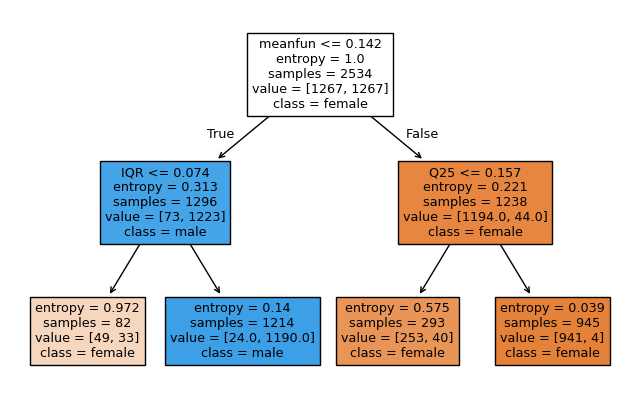

Оптимальное пороговое значение для фактора: 0.142
Процент наблюдений, для которых выполнено условие в корневой вершине: 51.1%
Процент наблюдений, для которых условие НЕ выполнено: 3.2%
Accuracy: 0.962


In [29]:
# Создаем модель дерева решений
dt_model = tree.DecisionTreeClassifier(
    max_depth=2,
    criterion='entropy',
    random_state=42
)

# Обучаем дерево на тренировочной выборке
dt_model.fit(X_train, y_train)

# Визуализация ввиде графа
plt.figure(figsize=(8, 5))
tree.plot_tree(
    dt_model,
    feature_names=X_train.columns,
    class_names=dt_model.classes_,
    filled=True
)
plt.show()

# Пороговое значение (наиболее информативное разбиение)
threshold = dt_model.tree_.threshold[0]
print(f'Оптимальное пороговое значение для фактора: {threshold:.3f}')

# Количество наблюдений в корневой вершине
root_samples = dt_model.tree_.n_node_samples[0]
# Количество объектов, которые ушли в левую и правую ветвь
left_samples = dt_model.tree_.n_node_samples[1]
right_samples = dt_model.tree_.n_node_samples[2]
# Рассчет процентов для левой и правой частей
left_percentage = left_samples / root_samples * 100
right_percentage = right_samples / root_samples * 100
print(f"Процент наблюдений, для которых выполнено условие в корневой вершине: {left_percentage:.1f}%")
print(f"Процент наблюдений, для которых условие НЕ выполнено: {right_percentage:.1f}%")

# Предсказание 
y_pred = dt_model.predict(X_test)

# Метрика
accuracy = metrics.accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.3f}")


Давайте дадим дереву решений полную свободу.

Создайте дерево решений, не ограничивая его максимальную глубину. В качестве критерия информативности используйте энтропию Шеннона.

В качестве значения параметра random_state возьмите 0.

Обучите модель на тренировочной выборке.

1. Чему равна глубина полученного дерева решения? Напомним, что глубину дерева можно узнать с помощью метода get_depth().
2. Чему равно количество листьев в полученном дереве решений? Напомним, что количество листьев можно узнать с помощью метода get_n_leaves().
3. Сделайте предсказание для обучающей и тестовой выборок и рассчитайте значение метрики accuracy на каждой из выборок. Ответы округлите до трёх знаков после точки-разделителя.

- accuracy на обучающей выборке.
- accuracy на тестовой выборке.

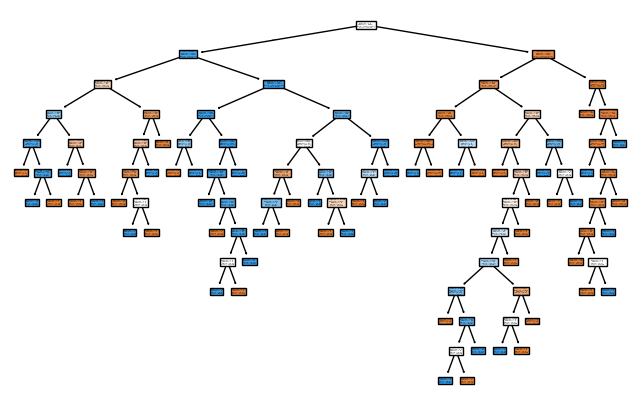

Глубина дерева: 12
Количество листьев: 54
Accuracy test: 0.973
Accuracy train: 1.000


In [ ]:
# Создаем модель дерева решений
dt_model = tree.DecisionTreeClassifier(
    criterion='entropy',
    random_state=0
)

# Обучаем дерево на тренировочной выборке
dt_model.fit(X_train, y_train)

# Визуализация ввиде графа
plt.figure(figsize=(8, 5))
tree.plot_tree(
    dt_model,
    feature_names=X_train.columns,
    class_names=dt_model.classes_,
    filled=True
)
plt.show()

# Максимальная глубина
print(f'Глубина дерева: {dt_model.get_depth()}')
# Количество листьев
print(f'Количество листьев: {dt_model.get_n_leaves()}')

# Предсказание 
y_train_pred = dt_model.predict(X_train)
y_test_pred = dt_model.predict(X_test)

# Метрика
accuracy_test = metrics.accuracy_score(y_test, y_test_pred)
accuracy_train = metrics.accuracy_score(y_train, y_train_pred)
print(f"Accuracy test: {accuracy_test:.3f}")
print(f"Accuracy train: {accuracy_train:.3f}")

Давайте попробуем найти оптимальные внешние параметры модели дерева решений для поставленной задачи. Воспользуемся классическим методом подбора гиперпараметров — перебором на сетке с кросс-валидацией (Grid SearchCV).

Задана сетка параметров:

В качестве кросс-валидатора будем использовать k-fold-валидатор со стратификацией (StratifiedKFold)

С помощью Grid SearchCV из модуля model_selection библиотеки sklearn переберите гиперпараметры дерева решений из приведённой сетки на обучающей выборке и найдите оптимальные. Параметр random_state для дерева решений установите равным 0. В качестве метрики качества (параметр scoring) используйте accuracy.

In [34]:
# Задаём сетку параметров
param_grid = {
    'criterion': ['gini', 'entropy'], # критерий информативности
    'max_depth': [4, 5, 6, 7, 8, 9, 10], # максимальная глубина дерева
    'min_samples_split': [3, 4, 5, 10] # минимальное количество объектов, необходимое для сплита
}

# Создаем модель дерева решений
dt_model = tree.DecisionTreeClassifier(
    criterion='entropy',
    random_state=0
)

# Создаем StratifiedKFold (стратифицированная кросс-валидация)
skf = model_selection.StratifiedKFold(n_splits=5)

# Создаем GridSearchCV с использованием StratifiedKFold
grid_search = model_selection.GridSearchCV(
    estimator=dt_model,
    param_grid=param_grid,
    cv=skf, # Используем StratifiedKFold
    scoring='accuracy',  # Метрика для выбора наилучших параметров
)

# Запускаем подбор параметров
grid_search.fit(X_train, y_train)

# Выводим наилучшие параметры и лучший результат
print(f"Лучшие параметры: {grid_search.best_params_}")
print(f"Лучший результат accuracy: {grid_search.best_score_:.3f}")

# Обучаем модель с лучшими параметрами
best_model = grid_search.best_estimator_

# Предсказание 
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

# Метрика
accuracy_test = metrics.accuracy_score(y_test, y_test_pred)
accuracy_train = metrics.accuracy_score(y_train, y_train_pred)
print(f"Accuracy test: {accuracy_test:.3f}")
print(f"Accuracy train: {accuracy_train:.3f}")

Лучшие параметры: {'criterion': 'gini', 'max_depth': 7, 'min_samples_split': 3}
Лучший результат accuracy: 0.966
Accuracy test: 0.970
Accuracy train: 0.996


Для оптимального дерева решений, построенного в задании 7.4, найдите важность каждого из факторов. Визуализируйте её в виде столбчатой диаграммы.

Выделите топ-3 наиболее важных факторов, участвующих в построении дерева решений:

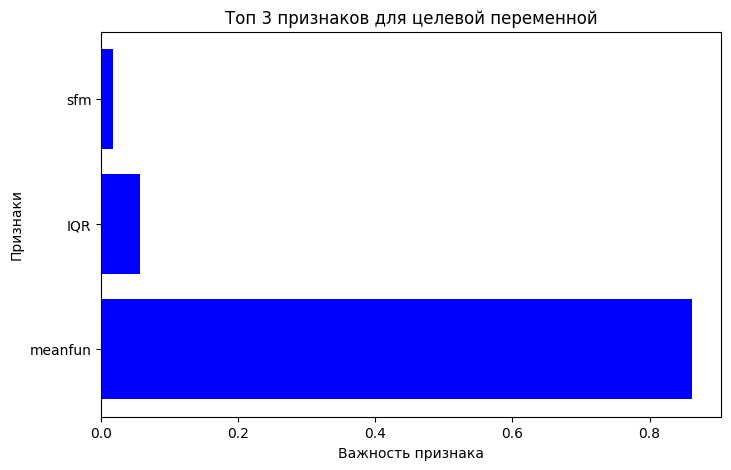

In [42]:
# Имена признаков
feature_names = X.columns
# Вычисляем значения информативности признаков
feature_importances = best_model.feature_importances_

# Сортируем важности по убыванию и получаем индексы
sorted_idx = np.argsort(feature_importances)[::-1]

# Сортируем признаки и их важность по убыванию
top_3_features = feature_names[sorted_idx][:3]
top_3_importances = feature_importances[sorted_idx][:3]

# Визуализация важности признаков
plt.figure(figsize=(8, 5))
plt.barh(
    top_3_features, 
    top_3_importances, 
    color='blue')
plt.xlabel("Важность признака")
plt.ylabel("Признаки")
plt.title("Топ 3 признаков для целевой переменной")
plt.show()